# 🎯 Flood Prediction - БЕЙСЛАЙН

## Базовое решение на sklearn (работает на любом Mac!)

Используем только проверенные библиотеки: pandas, numpy, sklearn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.auto import tqdm
from joblib import Parallel, delayed

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    VotingRegressor
)

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Библиотеки импортированы (с поддержкой параллелизма!)")


✅ Библиотеки импортированы (только sklearn - работает везде!)


## 1. Загрузка данных


In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nПервые строки:")
display(train.head())

features = [col for col in train.columns if col not in ['id', 'FloodProbability']]
X = train[features]
y = train['FloodProbability']
X_test = test[features]

print(f"\nПризнаков: {len(features)}")
print(f"Целевая переменная - диапазон: [{y.min():.3f}, {y.max():.3f}]")


Train shape: (1117957, 22)
Test shape: (745305, 21)

Первые строки:


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415



Признаков: 20
Целевая переменная - диапазон: [0.285, 0.725]


## 2. Предобработка данных


In [3]:
# Обработка выбросов методом Winsorization
def winsorize_outliers(df, features, lower=0.01, upper=0.99):
    df_copy = df.copy()
    for feature in features:
        lower_bound = df[feature].quantile(lower)
        upper_bound = df[feature].quantile(upper)
        df_copy[feature] = df_copy[feature].clip(lower=lower_bound, upper=upper_bound)
    return df_copy

X_processed = winsorize_outliers(X, features)
X_test_processed = winsorize_outliers(X_test, features)

print("✅ Выбросы обработаны (Winsorization 1%-99%)")


✅ Выбросы обработаны (Winsorization 1%-99%)


## 3. Генерация признаков


In [4]:
def generate_features(df):
    """Генерация базовых признаков"""
    df_new = df.copy()
    
    # Статистические признаки
    df_new['feature_sum'] = df.sum(axis=1)
    df_new['feature_mean'] = df.mean(axis=1)
    df_new['feature_std'] = df.std(axis=1)
    df_new['feature_max'] = df.max(axis=1)
    df_new['feature_min'] = df.min(axis=1)
    df_new['feature_range'] = df_new['feature_max'] - df_new['feature_min']
    df_new['feature_median'] = df.median(axis=1)
    
    # Взаимодействия ключевых признаков
    if 'MonsoonIntensity' in df.columns and 'TopographyDrainage' in df.columns:
        df_new['monsoon_x_drainage'] = df['MonsoonIntensity'] * df['TopographyDrainage']
    
    if 'Deforestation' in df.columns and 'Urbanization' in df.columns:
        df_new['deforest_x_urban'] = df['Deforestation'] * df['Urbanization']
    
    if 'ClimateChange' in df.columns and 'MonsoonIntensity' in df.columns:
        df_new['climate_x_monsoon'] = df['ClimateChange'] * df['MonsoonIntensity']
    
    # Полиномиальные признаки
    if 'MonsoonIntensity' in df.columns:
        df_new['monsoon_squared'] = df['MonsoonIntensity'] ** 2
        df_new['monsoon_sqrt'] = np.sqrt(df['MonsoonIntensity'])
    
    return df_new

print("🔧 Генерация признаков...")
with tqdm(total=2, desc="Feature Engineering") as pbar:
    X_with_features = generate_features(X_processed)
    pbar.update(1)
    X_test_with_features = generate_features(X_test_processed)
    pbar.update(1)

print(f"✅ Было признаков: {X_processed.shape[1]}")
print(f"✅ Стало признаков: {X_with_features.shape[1]}")
print(f"✅ Добавлено новых: {X_with_features.shape[1] - X_processed.shape[1]}")


🔧 Генерация признаков...


Feature Engineering:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Было признаков: 20
✅ Стало признаков: 32
✅ Добавлено новых: 12


In [5]:
# Масштабирование
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_with_features)
X_test_scaled = scaler.transform(X_test_with_features)

X_scaled = pd.DataFrame(X_scaled, columns=X_with_features.columns, index=X_with_features.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_with_features.columns, index=X_test_with_features.index)

# Разделение на train/val
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"✅ Масштабирование: RobustScaler")
print(f"Train: {X_train.shape}, Val: {X_val.shape}")


✅ Масштабирование: RobustScaler
Train: (894365, 32), Val: (223592, 32)


## 4. Обучение моделей

**⚡ Используется параллелизация:**
- Random Forest: `n_jobs=-1` (все CPU ядра для максимальной скорости)
- Histogram GB: автоматическая многопоточность


In [6]:
# Модель 1: Random Forest
print("🚀 Обучение Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1  # Включаем прогресс
)

with tqdm(total=1, desc="Random Forest") as pbar:
    rf_model.fit(X_train, y_train)
    pbar.update(1)

y_pred_rf = rf_model.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

print(f"Val RMSE: {rmse_rf:.6f}")
print(f"Val R²: {r2_rf:.6f}")


🚀 Обучение Random Forest...


Random Forest:   0%|          | 0/1 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   32.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   35.2s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s


Val RMSE: 0.019309
Val R²: 0.856565


[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.7s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.8s finished


In [7]:
# Модель 2: Gradient Boosting
print("\n🚀 Обучение Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42,
    verbose=1  # Включаем прогресс
)

with tqdm(total=1, desc="Gradient Boosting") as pbar:
    gb_model.fit(X_train, y_train)
    pbar.update(1)

y_pred_gb = gb_model.predict(X_val)
rmse_gb = np.sqrt(mean_squared_error(y_val, y_pred_gb))
r2_gb = r2_score(y_val, y_pred_gb)

print(f"Val RMSE: {rmse_gb:.6f}")
print(f"Val R²: {r2_gb:.6f}")



🚀 Обучение Gradient Boosting...


Gradient Boosting:   0%|          | 0/1 [00:00<?, ?it/s]

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.0024           0.0002            7.37m
         2           0.0022           0.0002            7.35m
         3           0.0020           0.0002            7.37m
         4           0.0019           0.0002            7.36m
         5           0.0017           0.0002            7.34m
         6           0.0016           0.0001            7.28m
         7           0.0015           0.0001            7.23m
         8           0.0014           0.0001            7.19m
         9           0.0013           0.0001            7.14m
        10           0.0012           0.0001            7.10m
        20           0.0007           0.0000            6.81m
        30           0.0005           0.0000            6.49m
        40           0.0004           0.0000            6.06m
        50           0.0004          -0.0000            5.64m
        60           0.0004          -0.0000            5.24m
       

In [8]:
# Модель 3: Histogram Gradient Boosting (быстрый!)
print("\n🚀 Обучение Histogram Gradient Boosting...")
hgb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbose=1  # Включаем прогресс
)

with tqdm(total=1, desc="Histogram GB") as pbar:
    hgb_model.fit(X_train, y_train)
    pbar.update(1)

y_pred_hgb = hgb_model.predict(X_val)
rmse_hgb = np.sqrt(mean_squared_error(y_val, y_pred_hgb))
r2_hgb = r2_score(y_val, y_pred_hgb)

print(f"Val RMSE: {rmse_hgb:.6f}")
print(f"Val R²: {r2_hgb:.6f}")



🚀 Обучение Histogram Gradient Boosting...


Histogram GB:   0%|          | 0/1 [00:00<?, ?it/s]

Binning 0.206 GB of training data: 0.130 s
Binning 0.023 GB of validation data: 0.008 s
Fitting gradient boosted rounds:
Fit 111 trees in 2.951 s, (3441 total leaves)
Time spent computing histograms: 1.843s
Time spent finding best splits:  0.087s
Time spent applying splits:      0.397s
Time spent predicting:           0.081s
Val RMSE: 0.019198
Val R²: 0.858203


## 5. Сравнение моделей


In [9]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Histogram GB'],
    'Val RMSE': [rmse_rf, rmse_gb, rmse_hgb],
    'Val R²': [r2_rf, r2_gb, r2_hgb]
}).sort_values('Val RMSE')

print("\n" + "="*60)
print("📊 РЕЗУЛЬТАТЫ БЕЙСЛАЙНА")
print("="*60)
display(results.style.background_gradient(cmap='RdYlGn_r', subset=['Val RMSE']))

print(f"\n🏆 Лучшая модель: {results.iloc[0]['Model']}")
print(f"✅ Validation RMSE: {results.iloc[0]['Val RMSE']:.6f}")



📊 РЕЗУЛЬТАТЫ БЕЙСЛАЙНА


,Model,Val RMSE,Val R²
1,Gradient Boosting,0.019175,0.858542
2,Histogram GB,0.019198,0.858203
0,Random Forest,0.019309,0.856565



🏆 Лучшая модель: Gradient Boosting
✅ Validation RMSE: 0.019175


## 6. Визуализация


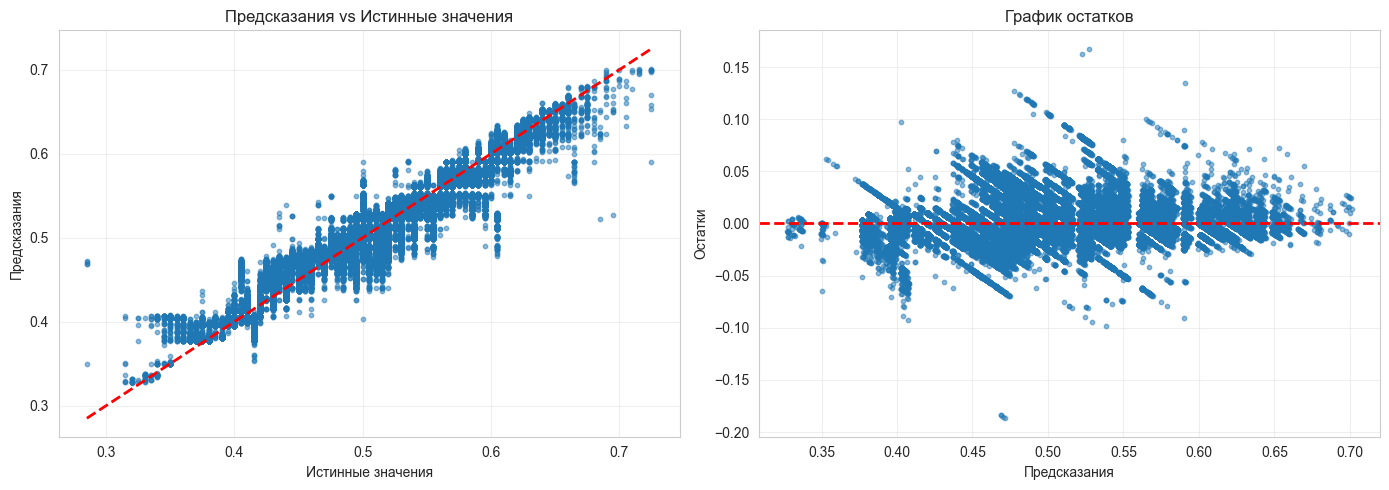

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_val, y_pred_hgb, alpha=0.5, s=10)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Истинные значения')
axes[0].set_ylabel('Предсказания')
axes[0].set_title('Предсказания vs Истинные значения')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_val - y_pred_hgb
axes[1].scatter(y_pred_hgb, residuals, alpha=0.5, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказания')
axes[1].set_ylabel('Остатки')
axes[1].set_title('График остатков')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Создание submission


In [11]:
# Предсказания на test
y_test_rf = rf_model.predict(X_test_scaled)
y_test_gb = gb_model.predict(X_test_scaled)
y_test_hgb = hgb_model.predict(X_test_scaled)

# Усреднение трех моделей
y_test_final = (y_test_rf + y_test_gb + y_test_hgb) / 3

# Создание submission
submission = pd.DataFrame({
    'id': test['id'],
    'FloodProbability': y_test_final
})

submission.to_csv('baseline_submission.csv', index=False)

print("✅ Файл baseline_submission.csv создан!")
print(f"\nСтатистика предсказаний:")
print(submission['FloodProbability'].describe())
print(f"\nПервые строки:")
display(submission.head(10))


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.4s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    2.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    2.2s finished


✅ Файл baseline_submission.csv создан!

Статистика предсказаний:
count    745305.000000
mean          0.504548
std           0.046893
min           0.327146
25%           0.475065
50%           0.493202
75%           0.538195
max           0.697625
Name: FloodProbability, dtype: float64

Первые строки:


,id,FloodProbability
0,1117957,0.577072
1,1117958,0.453672
2,1117959,0.449353
3,1117960,0.468857
4,1117961,0.469299
5,1117962,0.504635
6,1117963,0.537559
7,1117964,0.532723
8,1117965,0.474273
9,1117966,0.578382
